# CITS5508 Assignment 2

This notebook investigates two machine learning tasks:

1. Ensemble learning for binary heart disease prediction on the UCI processed Cleveland dataset.
2. PCA and k-Means clustering on the Olivetti Faces dataset.

The code uses fixed random seeds so that the train/test split, image sampling, and k-Means results are reproducible.

In [1]:
%matplotlib inline

from pathlib import Path
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

from sklearn.cluster import KMeans
from sklearn.compose import ColumnTransformer
from sklearn.datasets import fetch_olivetti_faces
from sklearn.decomposition import PCA
from sklearn.ensemble import AdaBoostClassifier, RandomForestClassifier, VotingClassifier
from sklearn.impute import SimpleImputer
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    accuracy_score,
    adjusted_rand_score,
    confusion_matrix,
    precision_recall_fscore_support,
    silhouette_samples,
    silhouette_score,
)
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from sklearn.tree import DecisionTreeClassifier

warnings.filterwarnings("ignore", category=FutureWarning)

RANDOM_STATE = 42
sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.dpi"] = 120
plt.rcParams["axes.titlesize"] = 11
plt.rcParams["axes.labelsize"] = 10

## 1. Ensemble Learning for Heart Disease Prediction

The first part compares a single decision tree with three ensemble approaches: Random Forest, AdaBoost, and soft voting.

### 1.1 Load and Describe the Dataset

The file `processed.cleveland.data` contains the processed Cleveland heart disease data. The original target `num` is an integer from 0 to 4. For this assignment it is binarised as:

- `0`: absence of heart disease.
- `1`: presence of heart disease, created from any original `num > 0`.

Missing values in `ca` and `thal` are represented by `?` in the source file. They are loaded as missing values and imputed inside the modelling pipeline using only the training split.

In [2]:
heart_columns = [
    "age", "sex", "cp", "trestbps", "chol", "fbs", "restecg",
    "thalach", "exang", "oldpeak", "slope", "ca", "thal", "num",
]

data_path = Path("processed.cleveland.data")
if not data_path.exists():
    raise FileNotFoundError(
        "processed.cleveland.data must be in the same directory as this notebook."
    )

heart = pd.read_csv(data_path, names=heart_columns, na_values="?")
heart["target"] = (heart["num"] > 0).astype(int)

print(f"Number of examples: {heart.shape[0]}")
print(f"Number of original attributes including target: {len(heart_columns)}")
print(f"Number of input features used for modelling: {len(heart_columns) - 1}")
display(heart.head())

Number of examples: 303
Number of original attributes including target: 14
Number of input features used for modelling: 13


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,num,target
0,63.0,1.0,1.0,145.0,233.0,1.0,2.0,150.0,0.0,2.3,3.0,0.0,6.0,0,0
1,67.0,1.0,4.0,160.0,286.0,0.0,2.0,108.0,1.0,1.5,2.0,3.0,3.0,2,1
2,67.0,1.0,4.0,120.0,229.0,0.0,2.0,129.0,1.0,2.6,2.0,2.0,7.0,1,1
3,37.0,1.0,3.0,130.0,250.0,0.0,0.0,187.0,0.0,3.5,3.0,0.0,3.0,0,0
4,41.0,0.0,2.0,130.0,204.0,0.0,2.0,172.0,0.0,1.4,1.0,0.0,3.0,0,0


In [3]:
numeric_features = ["age", "trestbps", "chol", "thalach", "oldpeak"]
categorical_features = ["sex", "cp", "fbs", "restecg", "exang", "slope", "ca", "thal"]

feature_description = pd.DataFrame(
    {
        "feature": numeric_features + categorical_features,
        "type": ["numeric"] * len(numeric_features) + ["categorical"] * len(categorical_features),
        "description": [
            "Age in years",
            "Resting blood pressure",
            "Serum cholesterol",
            "Maximum heart rate achieved",
            "ST depression induced by exercise relative to rest",
            "Sex",
            "Chest pain type",
            "Fasting blood sugar greater than 120 mg/dl",
            "Resting electrocardiographic results",
            "Exercise induced angina",
            "Slope of the peak exercise ST segment",
            "Number of major vessels coloured by fluoroscopy",
            "Thalassemia result",
        ],
    }
)

target_distribution = (
    heart["target"]
    .map({0: "0: no disease", 1: "1: disease"})
    .value_counts()
    .rename_axis("target")
    .reset_index(name="count")
)
target_distribution["percentage"] = (
    100 * target_distribution["count"] / target_distribution["count"].sum()
).round(2)

missing_values = (
    heart[heart_columns]
    .isna()
    .sum()
    .rename("missing_values")
    .to_frame()
)

print("Feature roles")
display(feature_description)
print("Binarised target distribution")
display(target_distribution)
print("Missing values")
display(missing_values.T)

Feature roles


,feature,type,description
0,age,numeric,Age in years
1,trestbps,numeric,Resting blood pressure
2,chol,numeric,Serum cholesterol
3,thalach,numeric,Maximum heart rate achieved
4,oldpeak,numeric,ST depression induced by exercise relative to ...
5,sex,categorical,Sex
6,cp,categorical,Chest pain type
7,fbs,categorical,Fasting blood sugar greater than 120 mg/dl
8,restecg,categorical,Resting electrocardiographic results
9,exang,categorical,Exercise induced angina


Binarised target distribution


,target,count,percentage
0,0: no disease,164,54.13
1,1: disease,139,45.87


Missing values


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,num
missing_values,0,0,0,0,0,0,0,0,0,0,0,4,2,0


Each example represents one patient. There are 13 input features. Five are continuous or numeric measurements, and eight are categorical or discrete clinical attributes. The target is close to balanced after binarisation, with a slight majority of patients having no disease.

### 1.2 Train/Test Split and Preprocessing

The dataset is split into 80% training and 20% testing, stratified by the binarised target. The preprocessing step is placed inside a scikit-learn `Pipeline` so that imputation and one-hot encoding are learned from the training data only.

In [4]:
X = heart.drop(columns=["num", "target"])
y = heart["target"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    stratify=y,
    random_state=RANDOM_STATE,
)

def make_one_hot_encoder():
    # scikit-learn 1.2 renamed the argument from sparse to sparse_output.
    try:
        return OneHotEncoder(handle_unknown="ignore", sparse_output=False)
    except TypeError:
        return OneHotEncoder(handle_unknown="ignore", sparse=False)

def make_preprocessor():
    numeric_transformer = SimpleImputer(strategy="median")
    categorical_transformer = Pipeline(
        steps=[
            ("imputer", SimpleImputer(strategy="most_frequent")),
            ("onehot", make_one_hot_encoder()),
        ]
    )
    return ColumnTransformer(
        transformers=[
            ("num", numeric_transformer, numeric_features),
            ("cat", categorical_transformer, categorical_features),
        ],
        remainder="drop",
    )

split_summary = pd.DataFrame(
    {
        "split": ["training", "testing"],
        "examples": [len(X_train), len(X_test)],
        "disease_rate": [y_train.mean(), y_test.mean()],
    }
)
split_summary["disease_rate"] = split_summary["disease_rate"].round(3)
display(split_summary)

,split,examples,disease_rate
0,training,242,0.459
1,testing,61,0.459


### 1.3-1.5 Fit the Baseline and Ensemble Models

The decision tree is regularised with a shallow maximum depth and a minimum leaf size, which is a sensible baseline for a small dataset. The Random Forest and AdaBoost models both use the required 500 estimators. AdaBoost uses decision stumps as weak learners with a conservative learning rate.

In [5]:
def make_adaboost_classifier():
    weak_learner = DecisionTreeClassifier(max_depth=1, random_state=RANDOM_STATE)
    try:
        return AdaBoostClassifier(
            estimator=weak_learner,
            n_estimators=500,
            learning_rate=0.05,
            algorithm="SAMME",
            random_state=RANDOM_STATE,
        )
    except TypeError:
        try:
            return AdaBoostClassifier(
                estimator=weak_learner,
                n_estimators=500,
                learning_rate=0.05,
                random_state=RANDOM_STATE,
            )
        except TypeError:
            return AdaBoostClassifier(
                base_estimator=weak_learner,
                n_estimators=500,
                learning_rate=0.05,
                algorithm="SAMME",
                random_state=RANDOM_STATE,
            )

def make_pipeline(model):
    return Pipeline(
        steps=[
            ("preprocess", make_preprocessor()),
            ("model", model),
        ]
    )

decision_tree = make_pipeline(
    DecisionTreeClassifier(
        max_depth=4,
        min_samples_leaf=5,
        random_state=RANDOM_STATE,
    )
)
random_forest = make_pipeline(
    RandomForestClassifier(
        n_estimators=500,
        min_samples_leaf=2,
        random_state=RANDOM_STATE,
        n_jobs=-1,
    )
)
adaboost = make_pipeline(make_adaboost_classifier())

voting_classifier = VotingClassifier(
    estimators=[
        ("decision_tree", decision_tree),
        ("random_forest", random_forest),
        ("adaboost", adaboost),
    ],
    voting="soft",
)

models = {
    "Decision Tree": decision_tree,
    "Random Forest": random_forest,
    "AdaBoost": adaboost,
    "Soft Voting": voting_classifier,
}

for model in models.values():
    model.fit(X_train, y_train)

print("All four models were fitted successfully.")

All four models were fitted successfully.


### 1.6 Compare Test Performance

Precision, recall, and F1-score are reported for the positive class, meaning the presence of heart disease. Accuracy is included as an additional reference but is not used as the main comparison metric.

In [6]:
evaluation_rows = []
predictions = {}

for name, model in models.items():
    y_pred = model.predict(X_test)
    predictions[name] = y_pred
    precision, recall, f1, _ = precision_recall_fscore_support(
        y_test,
        y_pred,
        average="binary",
        pos_label=1,
        zero_division=0,
    )
    evaluation_rows.append(
        {
            "model": name,
            "accuracy": accuracy_score(y_test, y_pred),
            "precision": precision,
            "recall": recall,
            "f1_score": f1,
        }
    )

evaluation_table = (
    pd.DataFrame(evaluation_rows)
    .sort_values("f1_score", ascending=False)
    .reset_index(drop=True)
)
display(evaluation_table.round(3))

,model,accuracy,precision,recall,f1_score
0,AdaBoost,0.902,0.867,0.929,0.897
1,Random Forest,0.869,0.812,0.929,0.867
2,Soft Voting,0.869,0.833,0.893,0.862
3,Decision Tree,0.770,0.719,0.821,0.767


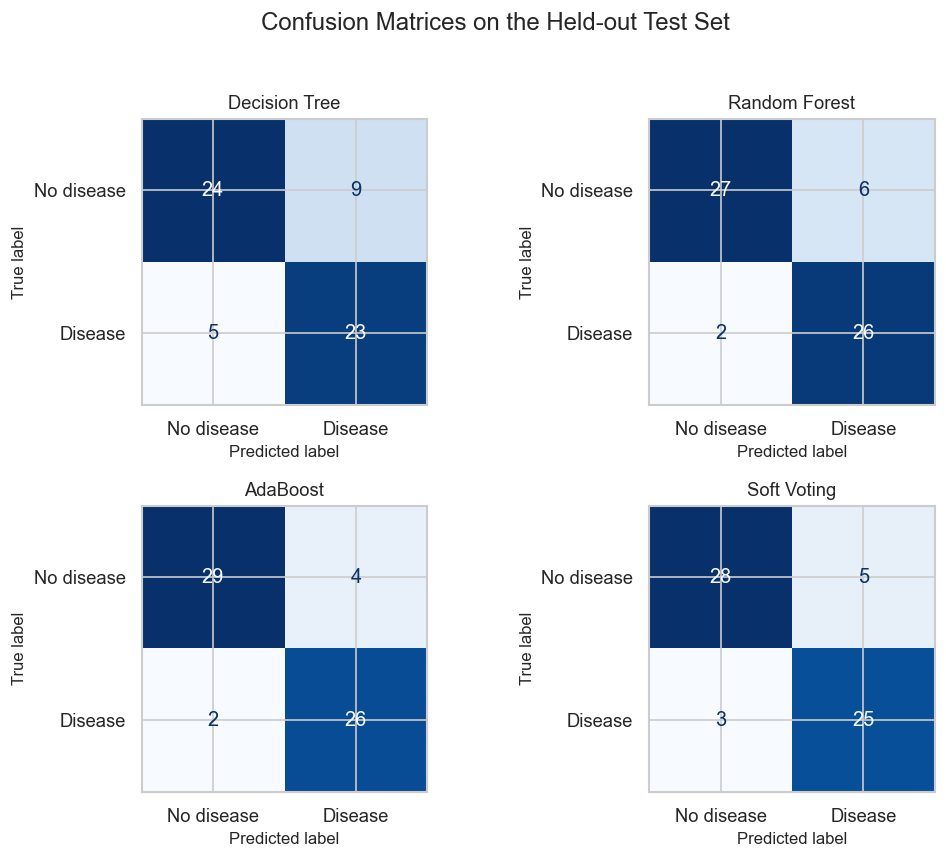

In [7]:
fig, axes = plt.subplots(2, 2, figsize=(9, 7))

for ax, (name, y_pred) in zip(axes.ravel(), predictions.items()):
    ConfusionMatrixDisplay.from_predictions(
        y_test,
        y_pred,
        display_labels=["No disease", "Disease"],
        cmap="Blues",
        colorbar=False,
        values_format="d",
        ax=ax,
    )
    ax.set_title(name)

fig.suptitle("Confusion Matrices on the Held-out Test Set", y=1.02)
plt.tight_layout()
plt.show()

In this stratified split, AdaBoost has the strongest F1-score and accuracy. Random Forest and soft voting are close behind, while the single decision tree is weaker. This is expected because a single tree can be sensitive to small changes in the training data, whereas ensembles reduce variance or bias by combining many trees.

### 1.7 Random Forest Feature Importances

Because categorical variables are one-hot encoded, the importances of their dummy variables are grouped back to the original clinical feature names before plotting.

,feature,importance
10,thal,0.2016
1,ca,0.1276
3,cp,0.1178
11,thalach,0.0813
4,exang,0.0763
6,oldpeak,0.0753
0,age,0.0633
2,chol,0.0617
9,slope,0.0612
8,sex,0.0499


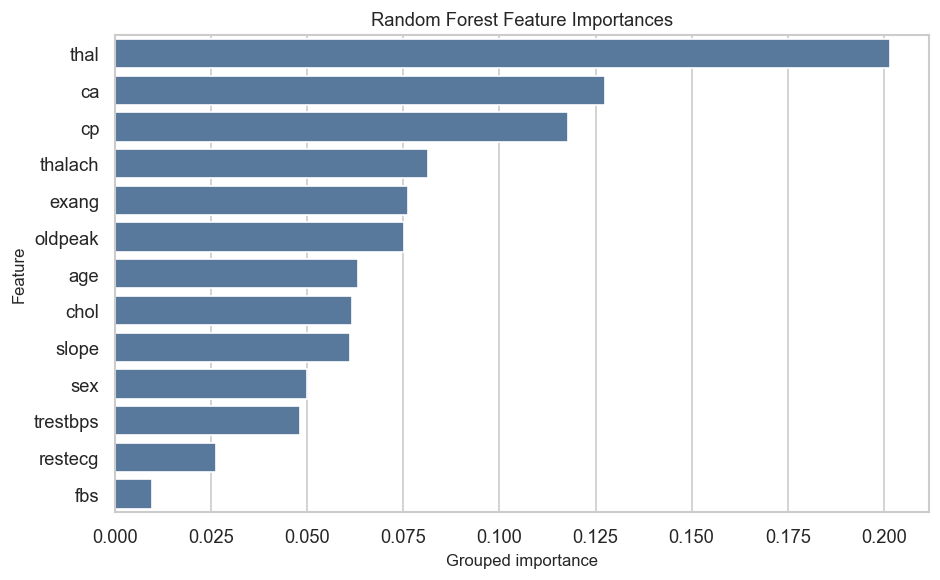

In [8]:
fitted_rf = models["Random Forest"]
transformed_feature_names = fitted_rf.named_steps["preprocess"].get_feature_names_out()
transformed_importances = fitted_rf.named_steps["model"].feature_importances_

transformed_importance_table = pd.DataFrame(
    {
        "transformed_feature": transformed_feature_names,
        "importance": transformed_importances,
    }
)

def original_feature_name(transformed_name):
    raw_name = transformed_name.split("__", 1)[-1]
    for feature in categorical_features:
        if raw_name == feature or raw_name.startswith(feature + "_"):
            return feature
    return raw_name

transformed_importance_table["feature"] = transformed_importance_table[
    "transformed_feature"
].map(original_feature_name)

grouped_importances = (
    transformed_importance_table
    .groupby("feature", as_index=False)["importance"]
    .sum()
    .sort_values("importance", ascending=False)
)

display(grouped_importances.round(4))

fig, ax = plt.subplots(figsize=(8, 5))
sns.barplot(
    data=grouped_importances,
    y="feature",
    x="importance",
    color="#4C78A8",
    ax=ax,
)
ax.set_title("Random Forest Feature Importances")
ax.set_xlabel("Grouped importance")
ax.set_ylabel("Feature")
plt.tight_layout()
plt.show()

The strongest features are typically `thal`, `ca`, `cp`, `thalach`, `exang`, and `oldpeak`. This is clinically plausible: thalassemia status, number of major vessels, chest pain type, maximum heart rate, exercise-induced angina, and ST depression all describe cardiovascular function or stress-test response. Features such as fasting blood sugar and resting ECG receive much lower importance in this model.

### 1.8 Detailed Comments on Ensemble Results

The models show the expected pattern for a small tabular classification problem. The single decision tree is interpretable, fast, and easy to explain, but it has higher variance because each split is chosen greedily from a limited training set. Random Forest improves this by bagging many decorrelated trees, which reduces variance and gives a more stable decision boundary. AdaBoost performs best in this run because it sequentially focuses on examples that earlier weak learners handled poorly, reducing bias when many simple decision stumps are combined.

Bagging and boosting address different weaknesses. Random Forest is usually more robust to noise because each tree is trained on a bootstrap sample and the final prediction averages many trees. AdaBoost can fit more precise boundaries by reweighting difficult examples, but this also means it can be more sensitive to noisy labels or outliers. On this dataset, the modest size and clinically meaningful non-linear patterns seem to favour boosting slightly.

The soft-voting classifier does not outperform AdaBoost here. Voting is useful when component models make complementary errors, but it can be pulled toward weaker members of the ensemble. Since the decision tree baseline is less accurate than the two ensemble models, averaging its probabilities with the stronger models does not guarantee a better result.

Overall, ensemble methods offer better predictive performance and stability than the single tree, but they are less transparent, require more computation, and have more hyperparameters. For clinical settings, this trade-off matters: an ensemble may be more accurate, while a single shallow tree may be easier to inspect and justify.

## 2. Clustering of Faces

The second part combines PCA with k-Means clustering on the Olivetti Faces dataset. The target labels are used only for visualisation and interpretation; k-Means itself is unsupervised.

### 2.1 Load and Describe the Olivetti Faces Dataset

Each example is a 64 x 64 greyscale face image flattened into 4096 pixel-intensity features. The dataset contains 40 people, with 10 images per person.

In [9]:
faces, face_targets = fetch_olivetti_faces(return_X_y=True, shuffle=False)

image_shape = (64, 64)
face_classes = np.unique(face_targets)
n_classes = len(face_classes)

faces_summary = pd.DataFrame(
    {
        "quantity": [
            "examples",
            "features per example",
            "image shape",
            "classes",
            "examples per class",
            "minimum pixel value",
            "maximum pixel value",
        ],
        "value": [
            faces.shape[0],
            faces.shape[1],
            f"{image_shape[0]} x {image_shape[1]}",
            n_classes,
            int(pd.Series(face_targets).value_counts().iloc[0]),
            float(faces.min()),
            float(faces.max()),
        ],
    }
)
display(faces_summary)

,quantity,value
0,examples,400
1,features per example,4096
2,image shape,64 x 64
3,classes,40
4,examples per class,10
5,minimum pixel value,0.0
6,maximum pixel value,1.0


The 4096 features are not independent hand-engineered variables. They are pixel intensities, so neighbouring features are spatially related. This high dimensionality is one reason PCA can be useful before clustering.

### 2.2 Random Example From Each Class

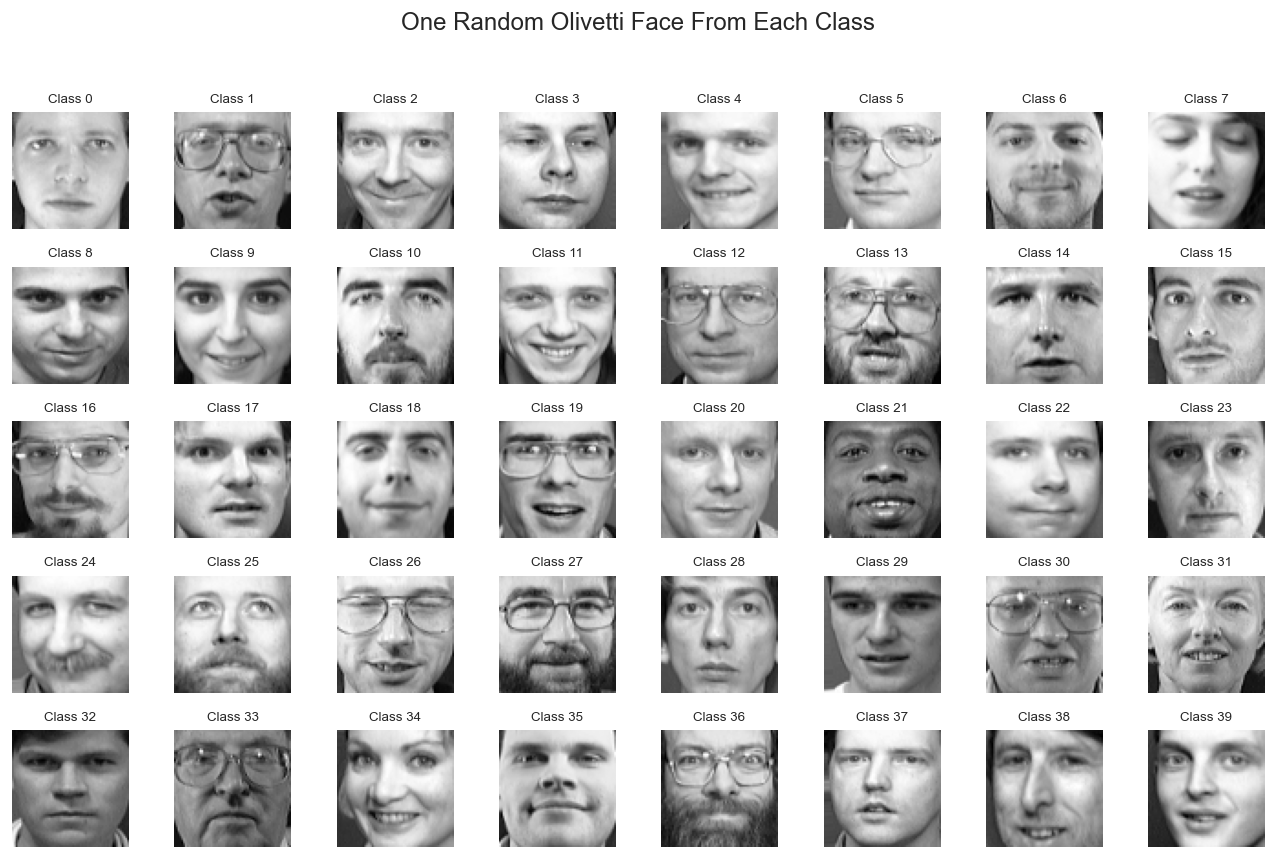

In [10]:
rng = np.random.default_rng(RANDOM_STATE)
sampled_indices = [
    int(rng.choice(np.flatnonzero(face_targets == class_label)))
    for class_label in face_classes
]

fig, axes = plt.subplots(5, 8, figsize=(11, 7))
for ax, idx in zip(axes.ravel(), sampled_indices):
    ax.imshow(faces[idx].reshape(image_shape), cmap="gray")
    ax.set_title(f"Class {face_targets[idx]}", fontsize=8)
    ax.axis("off")

fig.suptitle("One Random Olivetti Face From Each Class", y=1.02)
plt.tight_layout()
plt.show()

### 2.3 Principal Component Analysis

PCA is fitted on the full face matrix. The cumulative explained variance curve is used to choose the smallest number of components retaining at least 95% of the variance.

Components needed for at least 95% variance: 123
Cumulative variance retained: 0.9504


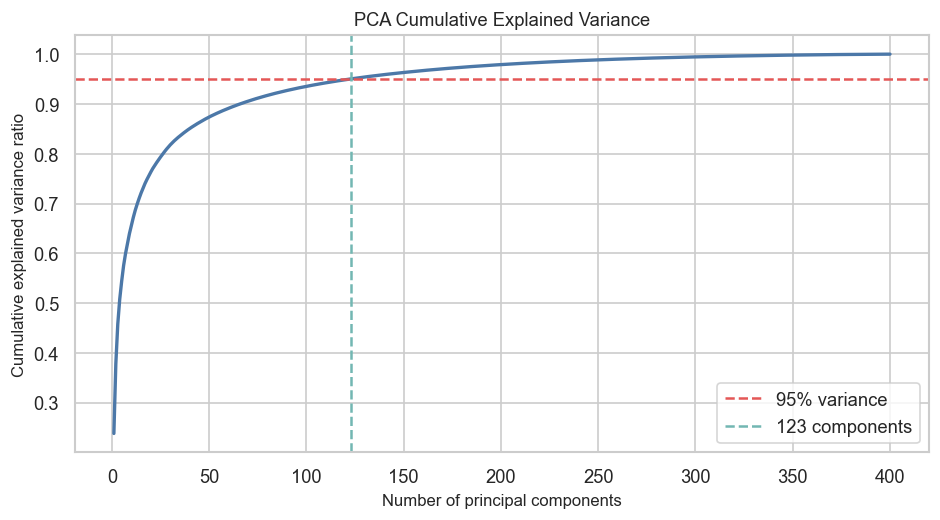

In [11]:
pca_full = PCA(svd_solver="full")
faces_pca_full = pca_full.fit_transform(faces)

cumulative_variance = np.cumsum(pca_full.explained_variance_ratio_)
n_components_95 = int(np.searchsorted(cumulative_variance, 0.95) + 1)

print(f"Components needed for at least 95% variance: {n_components_95}")
print(f"Cumulative variance retained: {cumulative_variance[n_components_95 - 1]:.4f}")

fig, ax = plt.subplots(figsize=(8, 4.5))
ax.plot(
    np.arange(1, len(cumulative_variance) + 1),
    cumulative_variance,
    color="#4C78A8",
    linewidth=2,
)
ax.axhline(0.95, color="#E45756", linestyle="--", label="95% variance")
ax.axvline(n_components_95, color="#72B7B2", linestyle="--", label=f"{n_components_95} components")
ax.set_xlabel("Number of principal components")
ax.set_ylabel("Cumulative explained variance ratio")
ax.set_title("PCA Cumulative Explained Variance")
ax.legend()
plt.tight_layout()
plt.show()

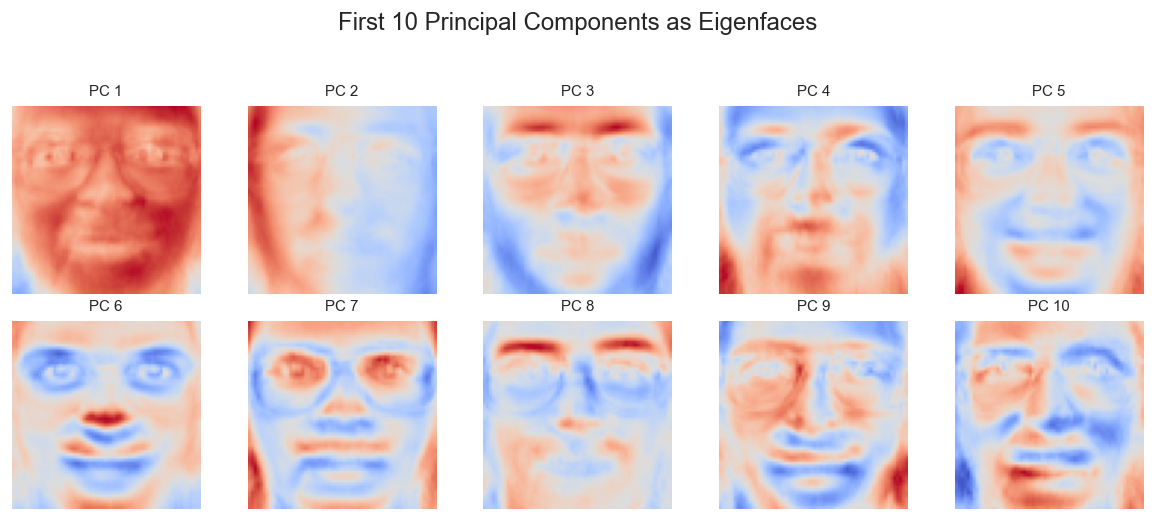

In [12]:
fig, axes = plt.subplots(2, 5, figsize=(10, 4.2))

for i, ax in enumerate(axes.ravel()):
    eigenface = pca_full.components_[i].reshape(image_shape)
    vmax = np.abs(eigenface).max()
    ax.imshow(eigenface, cmap="coolwarm", vmin=-vmax, vmax=vmax)
    ax.set_title(f"PC {i + 1}", fontsize=9)
    ax.axis("off")

fig.suptitle("First 10 Principal Components as Eigenfaces", y=1.03)
plt.tight_layout()
plt.show()

The eigenfaces are basis directions, not actual people. Light and dark regions show groups of pixels that vary together across the dataset. A face image can be approximated by adding a weighted combination of these eigenfaces to the mean face. Early components often capture broad changes such as lighting direction, head pose, and large facial structure.

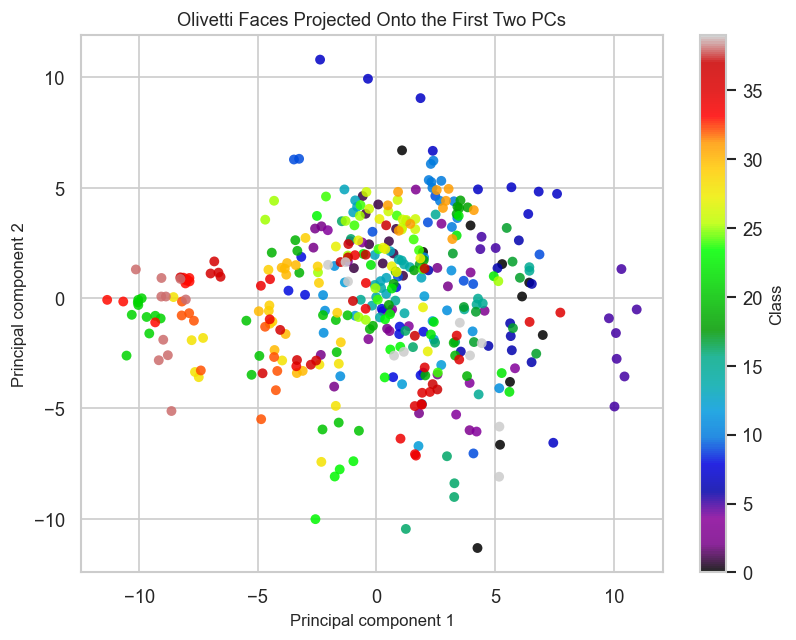

In [13]:
fig, ax = plt.subplots(figsize=(7, 5.5))
scatter = ax.scatter(
    faces_pca_full[:, 0],
    faces_pca_full[:, 1],
    c=face_targets,
    cmap="nipy_spectral",
    s=35,
    alpha=0.85,
    edgecolors="none",
)
cbar = fig.colorbar(scatter, ax=ax)
cbar.set_label("Class")
ax.set_xlabel("Principal component 1")
ax.set_ylabel("Principal component 2")
ax.set_title("Olivetti Faces Projected Onto the First Two PCs")
plt.tight_layout()
plt.show()

Two principal components are not sufficient to separate the 40 classes. The scatter plot shows substantial overlap, which is expected because two dimensions cannot preserve enough variation from 4096 pixel features to isolate each identity, pose, expression, and lighting pattern.

### 2.4 k-Means in the Original Feature Space

k-Means is first applied to the original 4096-dimensional pixel space using `k = 40`, the number of classes. The silhouette score measures how well separated the clusters are without using the true class labels.

In [14]:
kmeans_raw = KMeans(
    n_clusters=n_classes,
    n_init=50,
    random_state=RANDOM_STATE,
)
raw_cluster_labels = kmeans_raw.fit_predict(faces)

raw_silhouette = silhouette_score(faces, raw_cluster_labels)
raw_ari = adjusted_rand_score(face_targets, raw_cluster_labels)

print(f"Silhouette score in original feature space: {raw_silhouette:.4f}")
print(f"Adjusted Rand Index against true identities: {raw_ari:.4f}")

Silhouette score in original feature space: 0.1512
Adjusted Rand Index against true identities: 0.4214


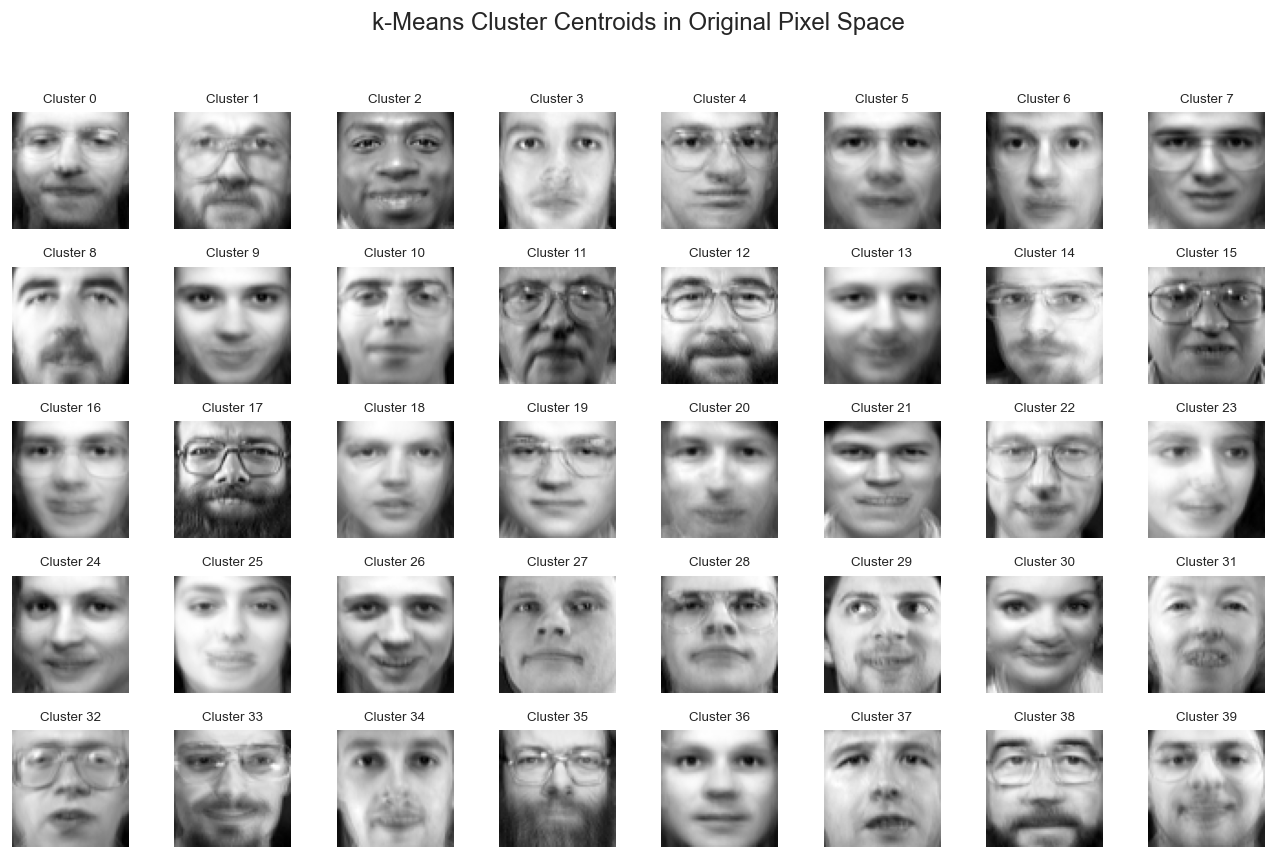

In [15]:
fig, axes = plt.subplots(5, 8, figsize=(11, 7))

for cluster_id, ax in enumerate(axes.ravel()):
    centroid_image = kmeans_raw.cluster_centers_[cluster_id].reshape(image_shape)
    ax.imshow(centroid_image, cmap="gray")
    ax.set_title(f"Cluster {cluster_id}", fontsize=8)
    ax.axis("off")

fig.suptitle("k-Means Cluster Centroids in Original Pixel Space", y=1.02)
plt.tight_layout()
plt.show()

Cluster centroids look like blurred average faces because each centroid is the mean of the images assigned to that cluster. This differs from eigenfaces: centroids are representative points in image space, while eigenfaces are signed variance directions used to reconstruct many images.

### 2.5 k-Means on PCA-Reduced Data

The clustering is repeated on the PCA representation retaining at least 95% of the variance.

In [16]:
faces_pca_95 = faces_pca_full[:, :n_components_95]

kmeans_pca = KMeans(
    n_clusters=n_classes,
    n_init=50,
    random_state=RANDOM_STATE,
)
pca_cluster_labels = kmeans_pca.fit_predict(faces_pca_95)

pca_silhouette = silhouette_score(faces_pca_95, pca_cluster_labels)
pca_ari = adjusted_rand_score(face_targets, pca_cluster_labels)

clustering_scores = pd.DataFrame(
    {
        "feature_space": ["Original 4096 pixels", f"PCA {n_components_95} components"],
        "silhouette_score": [raw_silhouette, pca_silhouette],
        "adjusted_rand_index": [raw_ari, pca_ari],
    }
)
display(clustering_scores.round(4))

,feature_space,silhouette_score,adjusted_rand_index
0,Original 4096 pixels,0.1512,0.4214
1,PCA 123 components,0.1719,0.4488


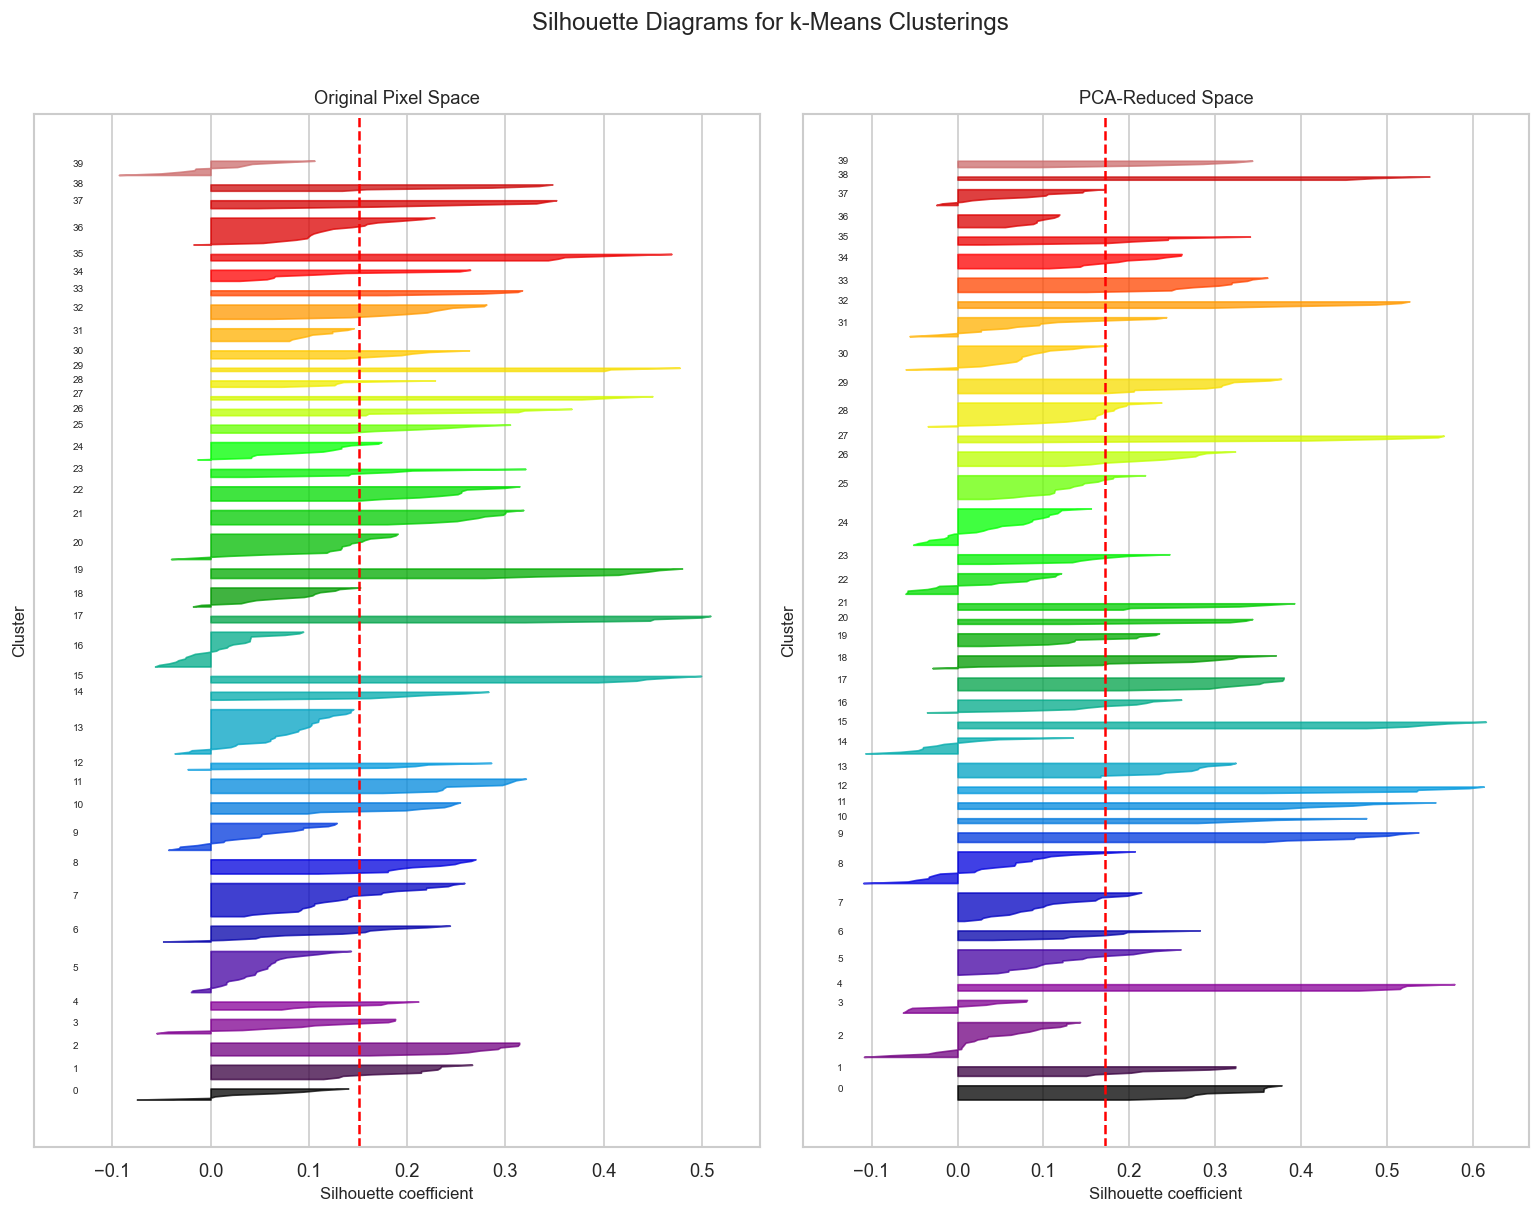

In [17]:
def plot_silhouette_diagram(data, cluster_labels, ax, title):
    sample_values = silhouette_samples(data, cluster_labels)
    cluster_ids = np.unique(cluster_labels)
    y_lower = 10

    for cluster_id in cluster_ids:
        values = sample_values[cluster_labels == cluster_id]
        values.sort()
        cluster_size = values.shape[0]
        y_upper = y_lower + cluster_size
        color = plt.cm.nipy_spectral(float(cluster_id) / len(cluster_ids))
        ax.fill_betweenx(
            np.arange(y_lower, y_upper),
            0,
            values,
            facecolor=color,
            edgecolor=color,
            alpha=0.75,
        )
        ax.text(-0.14, y_lower + 0.5 * cluster_size, str(cluster_id), fontsize=6)
        y_lower = y_upper + 5

    ax.axvline(np.mean(sample_values), color="red", linestyle="--", linewidth=1.5)
    ax.set_title(title)
    ax.set_xlabel("Silhouette coefficient")
    ax.set_ylabel("Cluster")
    ax.set_yticks([])
    ax.set_xlim([-0.18, max(0.55, sample_values.max() + 0.05)])

fig, axes = plt.subplots(1, 2, figsize=(13, 10), sharey=True)
plot_silhouette_diagram(faces, raw_cluster_labels, axes[0], "Original Pixel Space")
plot_silhouette_diagram(faces_pca_95, pca_cluster_labels, axes[1], "PCA-Reduced Space")
fig.suptitle("Silhouette Diagrams for k-Means Clusterings", y=1.01)
plt.tight_layout()
plt.show()

### 2.6 Detailed Comments on PCA and Clustering

PCA improves the k-Means result slightly in this run. The silhouette score is higher after reducing the data to the components that retain 95% of the variance, and the Adjusted Rand Index is also slightly higher. This suggests that PCA removes some low-variance pixel noise while preserving most of the identity-related structure needed by k-Means.

The improvement is modest rather than dramatic. A 95% variance threshold still keeps many components, and high-variance directions in face data are not always the same as identity-discriminating directions. Lighting, pose, and facial expression can dominate variance, so PCA is useful but not a complete solution for separating people.

The advantage of applying PCA before k-Means is that it reduces dimensionality, removes some noise, speeds up distance calculations, and makes Euclidean distances less affected by many weak pixel-level variations. It also gives useful visual diagnostics such as eigenfaces and two-dimensional projections. The disadvantage is that PCA is unsupervised and variance-based; it can discard low-variance information that might still help distinguish identities, and the transformed components are less directly interpretable than raw pixels.

Overall, PCA is a reasonable preprocessing step before k-Means for this dataset, but the clusters remain imperfect. The silhouette diagrams show that some clusters are compact and well separated, while others contain low or negative silhouette values, indicating overlapping or ambiguous assignments.

## Conclusion

For the heart disease task, ensembles outperform the single-tree baseline on the held-out test set, with AdaBoost giving the best F1-score in this reproducible split. For the face clustering task, PCA before k-Means gives a small improvement in cluster quality while also providing interpretable variance-based visualisations through eigenfaces.